# Baseline Fano Factor vs Baseline Firing Rate (session level)
Per session, average the **baseline-window** Fano factor and the **baseline-window** firing rate across neurons, then correlate the two across sessions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white' 

In [12]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
ff_path = prefix + 'neural/psths_fanofactor_per_neuron_all_regions_25-06-2026'
clustering_dir = prefix + 'clustering/'

BASELINE = (-0.2, 0.0)   # window (s) used for BOTH metrics

# Optional region filter applied to BOTH datasets: None keeps all
#   e.g. REGION_FILTER = ['CA1','DG','MRN','CP','LP','CA3']  or  'drop_root'
REGION_FILTER = None

# LDA (for color-coding the scatter)
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

def area_mask(area_series):
    if REGION_FILTER is None:
        return np.ones(len(area_series), dtype=bool)
    if REGION_FILTER == 'drop_root':
        return (area_series != 'root').values
    return area_series.isin(REGION_FILTER).values

## Session-averaged baseline Fano factor

In [13]:
ff = pd.read_parquet(ff_path)

ff_tcols = sorted([c for c in ff.columns if c.startswith('time_')], key=lambda x: int(x.split('_')[1]))
# the Fano-factor PSTH spans -0.5..1.0s over its time bins (same convention as ff_quench)
ff_tsec = np.linspace(-0.5, 1.0, len(ff_tcols))
ff_bcols = [c for c, m in zip(ff_tcols, (ff_tsec >= BASELINE[0]) & (ff_tsec <= BASELINE[1])) if m]
print(f"Fano factor: {len(ff_bcols)} baseline bins of {len(ff_tcols)}")

ff = ff[area_mask(ff['area'])]
ff['ff_baseline'] = ff[ff_bcols].mean(axis=1)                 # per-neuron baseline FF
ff_session = ff.groupby('session', as_index=False)['ff_baseline'].mean()  # avg across neurons
print(f"Sessions with FF: {len(ff_session)}; mean baseline FF = {ff_session['ff_baseline'].mean():.3f}")

Fano factor: 12 baseline bins of 85
Sessions with FF: 244; mean baseline FF = 1.717


## Session-averaged baseline firing rate

In [14]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])

# baseline columns from the first file (t_ columns are labelled in seconds)
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
fr_tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
fr_tsec = np.array([float(c.split('_')[1]) for c in fr_tcols])
fr_bcols = [c for c, m in zip(fr_tcols, (fr_tsec >= BASELINE[0]) & (fr_tsec <= BASELINE[1])) if m]
print(f"Firing rate: {len(fr_bcols)} baseline bins of {len(fr_tcols)}")

per_neuron = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[area_mask(d['area'])]
        if len(d) == 0:
            continue
        d['fr_baseline'] = np.nanmean(d[fr_bcols].values, axis=1)     # per-trial baseline FR
        g = d.groupby(['session', 'neuron_id'], as_index=False)['fr_baseline'].mean()  # per neuron
        per_neuron.append(g)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

fr_neuron = pd.concat(per_neuron, ignore_index=True)
fr_session = fr_neuron.groupby('session', as_index=False)['fr_baseline'].mean()  # avg across neurons
print(f"Sessions with FR: {len(fr_session)}; mean baseline FR = {fr_session['fr_baseline'].mean():.2f} Hz")

Firing rate: 12 baseline bins of 90
  100/380 files...
  200/380 files...
  300/380 files...
Sessions with FR: 244; mean baseline FR = 10.04 Hz


## Correlation

In [15]:
df = ff_session.merge(fr_session, on='session', how='inner')
df = df.merge(lda[['session', 'lda_1']], on='session', how='left').dropna(subset=['ff_baseline', 'fr_baseline'])

r, p = pearsonr(df['fr_baseline'], df['ff_baseline'])
rho, pp = spearmanr(df['fr_baseline'], df['ff_baseline'])
print("="*60)
print("Baseline Fano factor vs Baseline firing rate (session level)")
print("="*60)
print(f"n_sessions = {len(df)}")
print(f"pearson  r   = {r:+.3f}  p = {p:.3e}")
print(f"spearman rho = {rho:+.3f}  p = {pp:.3e}")

Baseline Fano factor vs Baseline firing rate (session level)
n_sessions = 244
pearson  r   = +0.286  p = 5.638e-06
spearman rho = +0.286  p = 5.456e-06


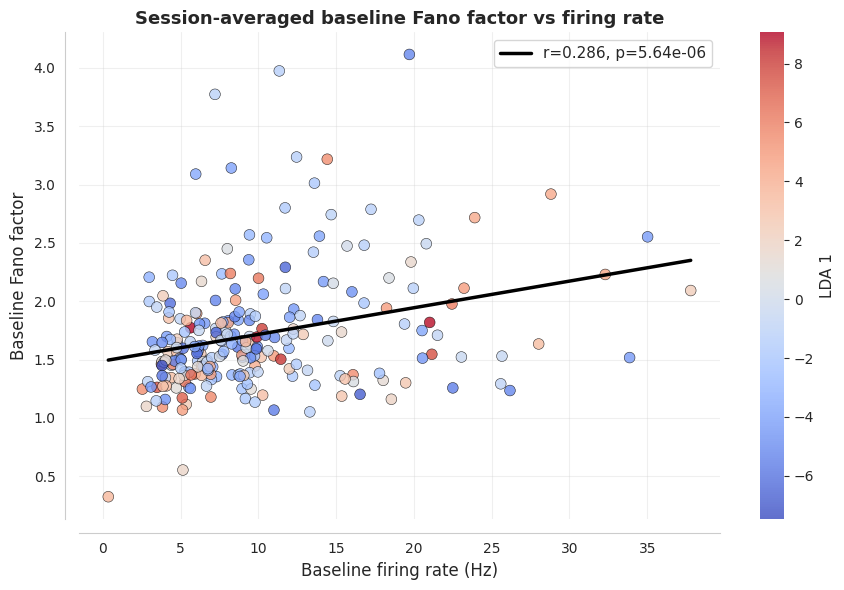

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
x = df['fr_baseline'].values
y = df['ff_baseline'].values
c = df['lda_1'].values

sc = ax.scatter(x, y, c=c, cmap='coolwarm', alpha=0.8, s=60,
                edgecolors='black', linewidth=0.4)
z = np.polyfit(x, y, 1)
xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.poly1d(z)(xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1', fontsize=11)
cbar.outline.set_visible(False)

ax.set_xlabel('Baseline firing rate (Hz)', fontsize=12)
ax.set_ylabel('Baseline Fano factor', fontsize=12)
ax.set_title('Session-averaged baseline Fano factor vs firing rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
sns.despine(ax=ax, offset=10)
plt.tight_layout()
plt.show()